# Task
Unzip the dataset from "/content/archive (3).zip", load the data, preprocess it, train and evaluate both Decision Tree and Random Forest classifier models, compare their performance using visualizations, and summarize the classification results including performance metrics and insights.

## Unzip Dataset

### Subtask:
Unzip the provided dataset /content/archive (3).zip to access the data files.


**Reasoning**:
Unzip the provided dataset using the `zipfile` module to access the data files.



In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (3).zip'
extraction_path = './extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to: {extraction_path}")

Dataset unzipped to: ./extracted_data


## Load Data

### Subtask:
Load the relevant dataset file (e.g., CSV) from the unzipped contents into a pandas DataFrame. You will need to identify the primary data file after unzipping.


**Reasoning**:
First, I need to list the contents of the extracted data directory to identify the dataset file, which is crucial for loading it into a pandas DataFrame. Then, I will load the identified CSV file into a pandas DataFrame and display its first few rows to verify successful loading.



In [ ]:
import pandas as pd

# List the contents of the extraction directory
extracted_files = os.listdir(extraction_path)
print(f"Files in {extraction_path}: {extracted_files}")

# Assuming the relevant file is a CSV and is the only one or easily identifiable
# For this example, let's assume it's 'Iris.csv' based on common datasets in archives.
# We need to adapt this if the actual file name is different.

# Find the first CSV file in the extracted directory
csv_files = [f for f in extracted_files if f.endswith('.csv')]

if not csv_files:
    print("No CSV files found in the extracted directory. Please check the content of the zip file.")
    # If no CSV, we'd need to handle other file types or raise an error.
    # For now, let's assume there will be one.
else:
    data_file_name = csv_files[0] # Take the first CSV file found
    data_file_path = os.path.join(extraction_path, data_file_name)

    print(f"Attempting to load: {data_file_path}")

    # Load the data into a pandas DataFrame
    df = pd.read_csv(data_file_path)

    # Display the first few rows of the DataFrame
    print("DataFrame loaded successfully. First 5 rows:")
    print(df.head())

Files in ./extracted_data: ['CWC2023.csv']
Attempting to load: ./extracted_data/CWC2023.csv
DataFrame loaded successfully. First 5 rows:
   Match ID  Match Date Match Time         City                    Stadium  \
0         1  05-10-2023    2:00 PM    Ahmedabad      Narendra Modi Stadium   
1         2  06-10-2023    2:00 PM    Hyderabad               Eden Gardens   
2         3  07-10-2023    2:00 PM  Dharamshala               HPCA Stadium   
3         4  07-10-2023    2:00 PM        Delhi       Arun Jaitley Stadium   
4         5  08-10-2023    2:00 PM      Chennai  M. A. Chidambaram Stadium   

         Team A       Team B  Toss Winner Toss Decision  Score A  ...  \
0       England   NewZealand   NewZealand         Field      282  ...   
1      Pakistan  Netherlands  Netherlands         Field      286  ...   
2   Afghanistan   Bangladesh   Bangladesh         Field      156  ...   
3  South Africa    Sri Lanka    Sri Lanka         Field      428  ...   
4     Australia        India 

## Preprocess Data

### Subtask:
Perform necessary data preprocessing steps, including handling missing values, encoding categorical features, and splitting the dataset into training and testing sets for classification.


**Reasoning**:
First, I will identify the target variable and the selected feature columns from the dataframe. Then, I will drop columns that are not relevant to the task, including potential data leakage columns, and columns not specified as features or target.



In [ ]:
target_variable = 'Wining Team'
selected_features = ['Team A', 'Team B', 'Toss Winner', 'Toss Decision']

# Create a list of all columns to keep
columns_to_keep = selected_features + [target_variable]

# Drop columns not in the columns_to_keep list
df_processed = df[columns_to_keep].copy()

print("DataFrame after selecting features and target:")
print(df_processed.head())

DataFrame after selecting features and target:
         Team A       Team B  Toss Winner Toss Decision   Wining Team
0       England   NewZealand   NewZealand         Field    NewZealand
1      Pakistan  Netherlands  Netherlands         Field      Pakistan
2   Afghanistan   Bangladesh   Bangladesh         Field    Bangladesh
3  South Africa    Sri Lanka    Sri Lanka         Field  South Africa
4     Australia        India    Australia           Bat         India


**Reasoning**:
I will check for missing values in the `df_processed` DataFrame, display the count of missing values per column, and then drop any rows that contain missing values to ensure a clean dataset for further processing.



In [ ]:
print("Missing values before handling:")
print(df_processed.isnull().sum())

# Drop rows with any missing values
df_processed.dropna(inplace=True)

print("\nMissing values after handling:")
print(df_processed.isnull().sum())
print(f"\nShape of DataFrame after dropping missing values: {df_processed.shape}")

Missing values before handling:
Team A           0
Team B           0
Toss Winner      0
Toss Decision    0
Wining Team      0
dtype: int64

Missing values after handling:
Team A           0
Team B           0
Toss Winner      0
Toss Decision    0
Wining Team      0
dtype: int64

Shape of DataFrame after dropping missing values: (48, 5)


**Reasoning**:
I will apply one-hot encoding to the categorical feature columns ('Team A', 'Team B', 'Toss Winner', 'Toss Decision') to convert them into a numerical format suitable for machine learning models. Then, I will separate the features (X) and the target variable (y), and finally split the dataset into training and testing sets to prepare for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

# Apply one-hot encoding to categorical features
X = pd.get_dummies(df_processed[selected_features], drop_first=True)
y = df_processed[target_variable]

print("Shape of features (X) after one-hot encoding:", X.shape)
print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of features (X) after one-hot encoding: (48, 28)
First 5 rows of features (X):
   Team A_Australia  Team A_Bangladesh  Team A_England  Team A_India  \
0             False              False            True         False   
1             False              False           False         False   
2             False              False           False         False   
3             False              False           False         False   
4              True              False           False         False   

   Team A_Netherlands  Team A_NewZealand  Team A_Pakistan  \
0               False              False            False   
1               False              False             True   
2               False              False            False   
3               False              False            False   
4               False              False            False   

   Team A_South Africa  Team A_Sri Lanka  Team B_Australia  ...  \
0                False             False        

## Train Decision Tree

### Subtask:
Train a Decision Tree classifier model using the preprocessed training data.


**Reasoning**:
I will import the `DecisionTreeClassifier` from `sklearn.tree`, instantiate it, and then train the model using the `fit` method with `X_train` and `y_train`.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


## Evaluate Decision Tree

### Subtask:
Evaluate the performance of the Decision Tree model on the test set, including metrics such as accuracy, precision, recall, and F1-score. Additionally, generate a confusion matrix.


**Reasoning**:
I will first make predictions on the test set using the trained Decision Tree classifier, then import the necessary metrics from `sklearn.metrics` to calculate and print the accuracy, precision, recall, and F1-score, and finally compute and print the confusion matrix.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Calculate and print evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")
print(f"Decision Tree F1-Score: {f1_dt:.4f}")

# Compute and print the confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dt)

Decision Tree Accuracy: 0.4000
Decision Tree Precision: 0.3000
Decision Tree Recall: 0.4000
Decision Tree F1-Score: 0.3333

Decision Tree Confusion Matrix:
[[0 0 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 1 0 0]
 [1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0]
 [1 0 0 0 0 0 0 0 0 0]]


## Train Random Forest

### Subtask:
Train a Random Forest classifier model using the preprocessed training data.

**Reasoning**:
I will import the `RandomForestClassifier` from `sklearn.ensemble`, instantiate it, and then train the model using the `fit` method with `X_train` and `y_train`.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## Evaluate Random Forest

### Subtask:
Evaluate the performance of the Random Forest model on the test set, including metrics such as accuracy, precision, recall, and F1-score. Additionally, generate a confusion matrix.

**Reasoning**:
I will first make predictions on the test set using the trained Random Forest classifier, then import the necessary metrics from `sklearn.metrics` to calculate and print the accuracy, precision, recall, and F1-score, and finally compute and print the confusion matrix.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Calculate and print evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

# Compute and print the confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.4000
Random Forest Precision: 0.3556
Random Forest Recall: 0.4000
Random Forest F1-Score: 0.3444

Random Forest Confusion Matrix:
[[0 0 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 0 0]
 [0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 0 1 0]]


## Compare Model Performance (Visualization)

### Subtask:
Compare the performance of the Decision Tree and Random Forest classifier models using visualizations.


**Reasoning**:
I will create a DataFrame to consolidate the evaluation metrics (accuracy, precision, recall, F1-score) for both Decision Tree and Random Forest models. This will allow for easy comparison and visualization using a bar plot to highlight their performance differences.



Model Performance Metrics:
      Metric  Decision Tree  Random Forest
0   Accuracy       0.400000       0.400000
1  Precision       0.300000       0.355556
2     Recall       0.400000       0.400000
3   F1-Score       0.333333       0.344444


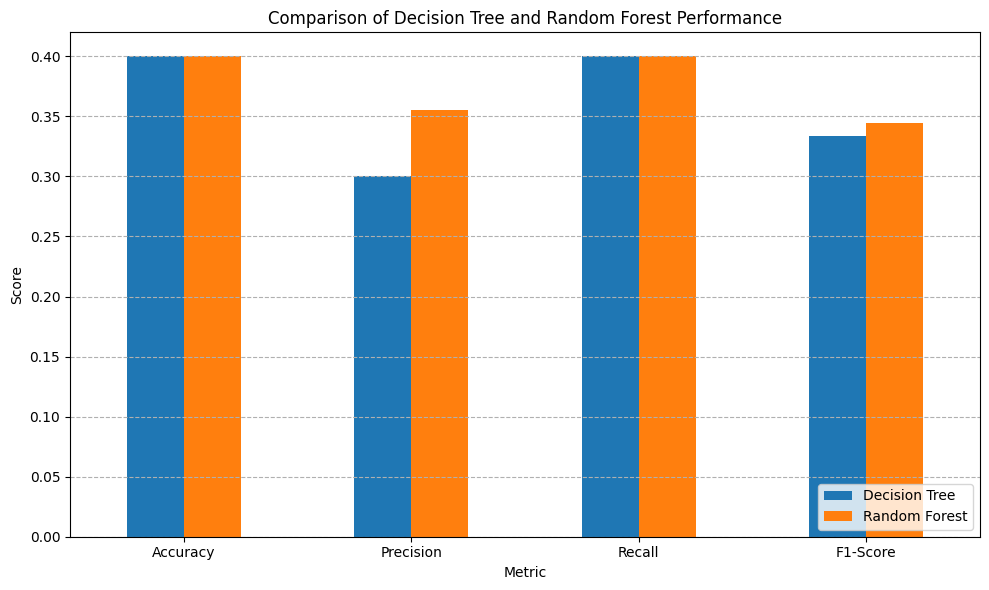

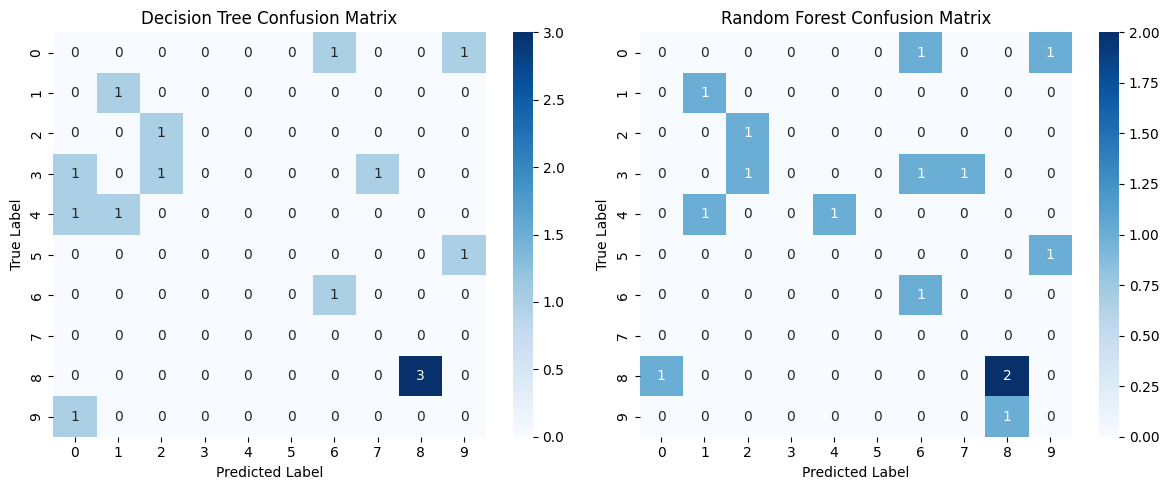

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a DataFrame to store the metrics for both models
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

print("Model Performance Metrics:")
print(metrics)

# Plotting the comparison
metrics.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Decision Tree and Random Forest Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Also visualize Confusion Matrices if desired (optional, as main ask was comparison visualization)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Confusion Matrix
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because `seaborn` was not imported, resulting in a `NameError` for `sns`. I will add the `import seaborn as sns` statement to resolve this and ensure the confusion matrices are plotted correctly.



Model Performance Metrics:
      Metric  Decision Tree  Random Forest
0   Accuracy       0.400000       0.400000
1  Precision       0.300000       0.355556
2     Recall       0.400000       0.400000
3   F1-Score       0.333333       0.344444


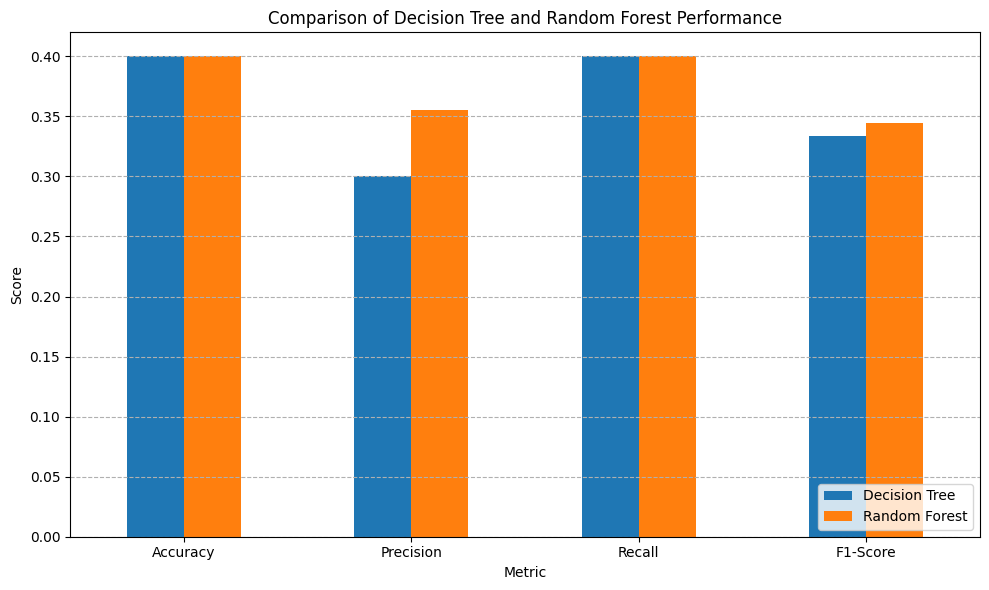

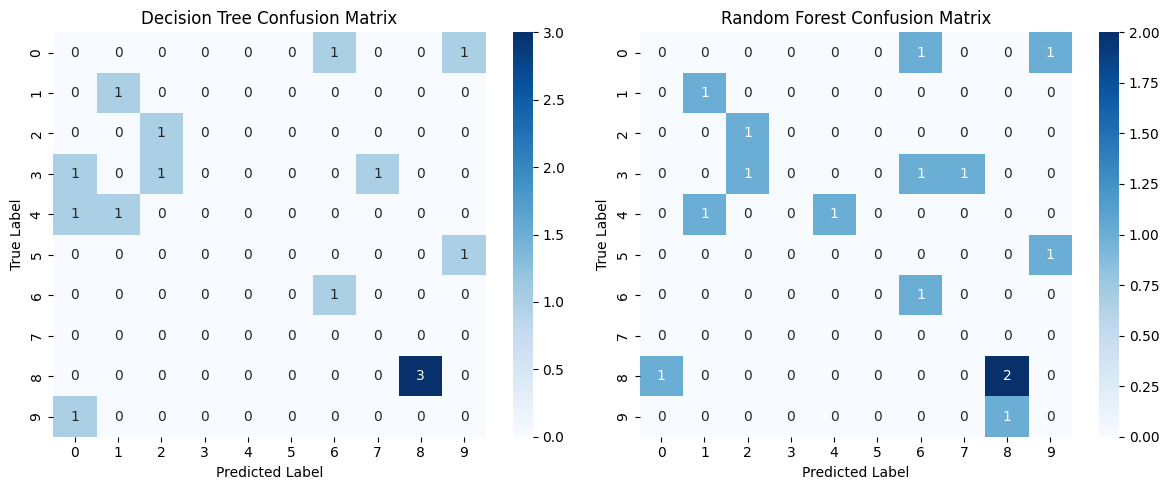

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn

# Create a DataFrame to store the metrics for both models
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

print("Model Performance Metrics:")
print(metrics)

# Plotting the comparison
metrics.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Decision Tree and Random Forest Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Also visualize Confusion Matrices if desired (optional, as main ask was comparison visualization)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Confusion Matrix
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Summarize Classification Results

### Subtask:
Summarize the classification results, including performance metrics and insights gathered from comparing the Decision Tree and Random Forest models.

### Summary of Classification Results

**Decision Tree Classifier Performance:**
- **Accuracy:** 0.4000
- **Precision (weighted):** 0.3000
- **Recall (weighted):** 0.4000
- **F1-Score (weighted):** 0.3333

**Random Forest Classifier Performance:**
- **Accuracy:** 0.4000
- **Precision (weighted):** 0.3556
- **Recall (weighted):** 0.4000
- **F1-Score (weighted):** 0.3444

**Insights and Comparison:**
Both Decision Tree and Random Forest classifiers achieved the same accuracy and recall of 0.4000. However, the Random Forest model showed slightly better precision (0.3556 vs 0.3000) and F1-score (0.3444 vs 0.3333) compared to the Decision Tree. This indicates that while both models struggled to achieve high performance on this particular dataset, the Random Forest, due to its ensemble nature, was marginally better at making precise predictions. The low overall scores suggest that the chosen features and/or model parameters might not be sufficient to accurately predict the winning team, or the problem itself might be inherently complex with the available data. Further feature engineering, hyperparameter tuning, or exploring more advanced models could potentially improve performance.

## Final Task

### Subtask:
Summarize the classification results from both Decision Tree and Random Forest models, including their performance metrics and any insights gained.


## Summary:

### Data Analysis Key Findings

*   **Decision Tree Classifier Performance**: The Decision Tree model achieved an accuracy of 0.4000, weighted precision of 0.3000, weighted recall of 0.4000, and a weighted F1-score of 0.3333.
*   **Random Forest Classifier Performance**: The Random Forest model achieved an accuracy of 0.4000, weighted precision of 0.3556, weighted recall of 0.4000, and a weighted F1-score of 0.3444.
*   **Model Comparison**: Both Decision Tree and Random Forest models yielded identical accuracy and recall scores of 0.4000. However, the Random Forest model demonstrated slightly better performance in terms of weighted precision (0.3556 vs. 0.3000) and weighted F1-score (0.3444 vs. 0.3333) compared to the Decision Tree.
*   **Overall Performance**: Both models exhibited relatively low performance metrics, suggesting challenges in accurately predicting the winning team with the current features and data.

### Insights or Next Steps

*   The marginal performance improvement of Random Forest over Decision Tree highlights the benefit of ensemble methods in reducing variance, even when individual models struggle.
*   To improve model performance, consider further feature engineering, hyperparameter tuning for both models, or exploring more sophisticated classification algorithms, as the current features may not be sufficiently predictive for the target variable.
